<a href="https://colab.research.google.com/github/nataliatheodorou123/---/blob/main/%CE%95%CF%81%CE%B3%CE%B1%CF%83%CE%AF%CE%B1%201-%CE%9D%CE%B1%CF%84%CE%B1%CE%BB%CE%AF%CE%B1%20%CE%98%CE%B5%CE%BF%CE%B4%CF%8E%CF%81%CE%BF%CF%85%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/advertising.csv')
print("DataFrame 'df' loaded successfully. Displaying the first 5 rows:")
print(df.head())

DataFrame 'df' loaded successfully. Displaying the first 5 rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [7]:
print("Displaying the first 5 rows of the DataFrame:")
print(df.head())


# Define features (X) and target variable (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("\nFeatures (X) and Target (y) defined successfully.")
print("First 5 rows of Features (X):")
print(X.head())
print("\nFirst 5 rows of Target (y):")
print(y.head())

Displaying the first 5 rows of the DataFrame:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Features (X) and Target (y) defined successfully.
First 5 rows of Features (X):
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

First 5 rows of Target (y):
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets successfully.
Shape of X_train: (160, 3)
Shape of X_test: (40, 3)
Shape of y_train: (160,)
Shape of y_test: (40,)


In [8]:
from sklearn.linear_model import LinearRegression

# Instantiate the model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Linear Regression model trained successfully.
Model coefficients: [0.05450927 0.10094536 0.00433665]
Model intercept: 4.714126402214127


In [5]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

Model Evaluation Metrics:
R-squared: 0.9059
Mean Absolute Error (MAE): 1.2748
Mean Squared Error (MSE): 2.9078


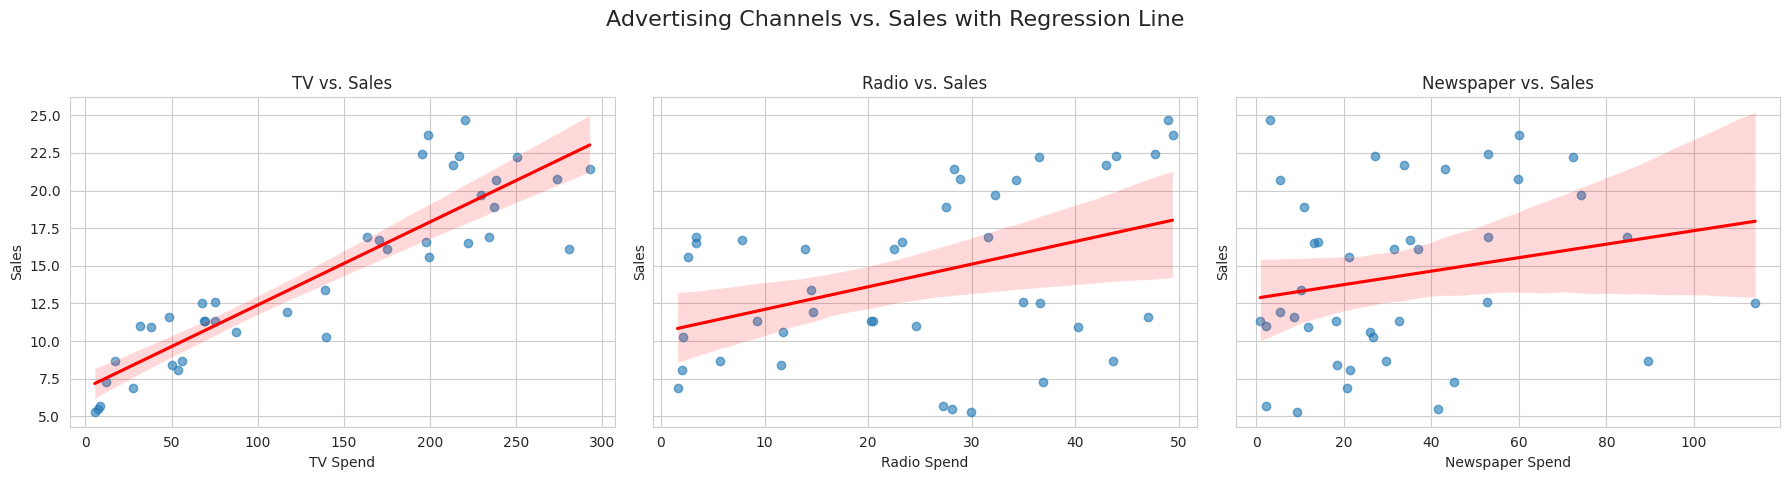

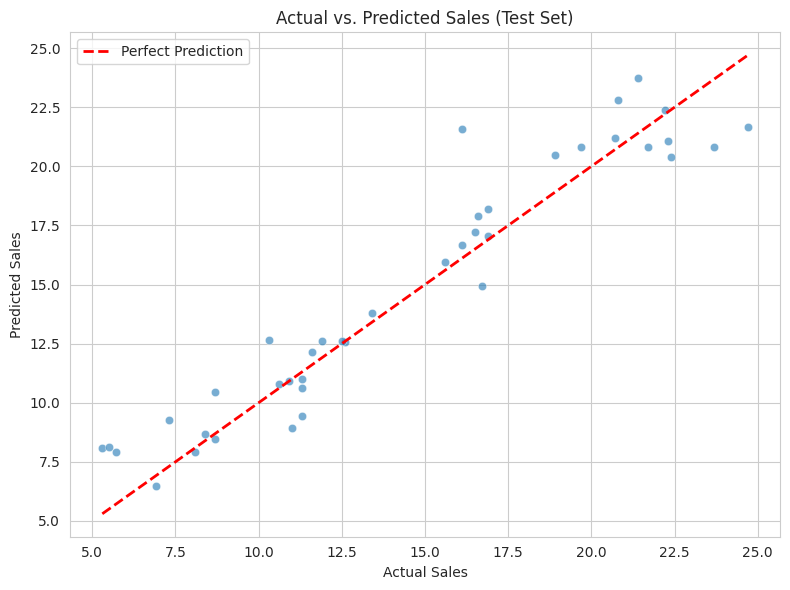

Visualization of model predictions and actual vs. predicted sales completed.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Create subplots for each advertising channel
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Advertising Channels vs. Sales with Regression Line', fontsize=16)

for i, channel in enumerate(X_test.columns):
    sns.regplot(x=X_test[channel], y=y_test, ax=axes[i], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    axes[i].set_title(f'{channel} vs. Sales')
    axes[i].set_xlabel(f'{channel} Spend')
    axes[i].set_ylabel('Sales')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Create a scatter plot of Actual vs. Predicted Sales
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Sales (Test Set)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Visualization of model predictions and actual vs. predicted sales completed.")